# Initial imports and code cleaning:
* 4.8_data_clean_v1-Copy1.ipynb by Mengyi

In [2]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import missingno as msno
import shap
import xgboost as xgb
sb.set()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from pywaffle import Waffle

In [3]:
# Load dataset
sleepData = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
sleepData.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
sleepData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
sleepData = sleepData.drop_duplicates()
sleepData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [6]:
# Reformat BMI Category
sleepData["BMI Category"].unique()
sleepData["BMI Category"] = sleepData["BMI Category"].map({
    "Overweight": "Overweight",
    "Normal": "Normal",
    "Normal Weight": "Normal",
    "Obese": "Obese"
})
sleepData.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [7]:
sleepData[['Systolic_BP', 'Diastolic_BP']] = sleepData['Blood Pressure'].str.split('/', expand=True).astype(int)
sleepData.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [8]:
print(sleepData.describe())
print(sleepData.isnull().sum())

        Person ID         Age  Sleep Duration  Quality of Sleep  \
count  374.000000  374.000000      374.000000        374.000000   
mean   187.500000   42.184492        7.132086          7.312834   
std    108.108742    8.673133        0.795657          1.196956   
min      1.000000   27.000000        5.800000          4.000000   
25%     94.250000   35.250000        6.400000          6.000000   
50%    187.500000   43.000000        7.200000          7.000000   
75%    280.750000   50.000000        7.800000          8.000000   
max    374.000000   59.000000        8.500000          9.000000   

       Physical Activity Level  Stress Level  Heart Rate   Daily Steps  \
count               374.000000    374.000000  374.000000    374.000000   
mean                 59.171123      5.385027   70.165775   6816.844920   
std                  20.830804      1.774526    4.135676   1617.915679   
min                  30.000000      3.000000   65.000000   3000.000000   
25%                  45.00

In [9]:
sleepData["Sleep Disorder"].fillna(value = "NA", inplace = True)
sleepData.head()

C:\Users\User\AppData\Local\Temp\ipykernel_13988\3548581568.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sleepData["Sleep Disorder"].fillna(value = "NA", inplace = True)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NA,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NA,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NA,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [10]:
print(sleepData.isnull().sum())

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic_BP                0
Diastolic_BP               0
dtype: int64


In [11]:
sleepData.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NA,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NA,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NA,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [12]:
# Drop irrelevant columns
sleepData = sleepData.drop("Person ID", axis = 1)
sleepData.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NA,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NA,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NA,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


# EDA

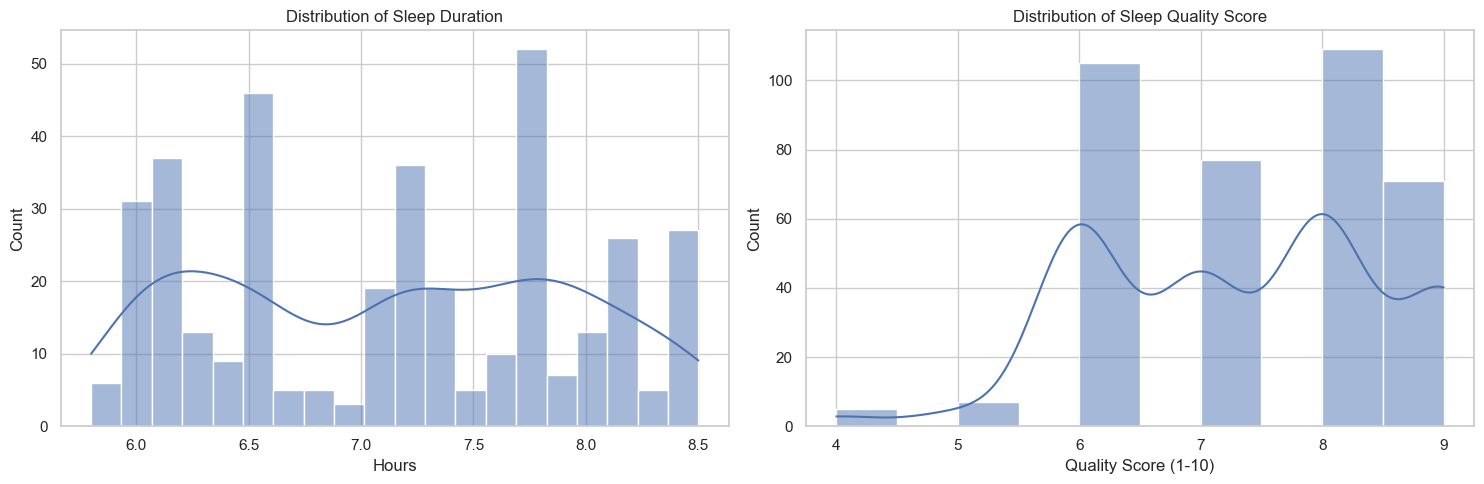

In [14]:
# Set up the visualization style
sb.set_style("whitegrid")
plt.figure(figsize=(15, 5))

# Sleep Duration Distribution
plt.subplot(1, 2, 1)
sb.histplot(sleepData['Sleep Duration'], kde=True, bins=20)
plt.title('Distribution of Sleep Duration')
plt.xlabel('Hours')

# Sleep Quality Score Distribution
plt.subplot(1, 2, 2)
sb.histplot(sleepData['Quality of Sleep'], kde=True, bins=10)
plt.title('Distribution of Sleep Quality Score')
plt.xlabel('Quality Score (1-10)')

plt.tight_layout()
plt.show()

Sleep Duration:
Most people sleep between 6–8 hours.
Few people have very short (<5h) or very long (>9h) sleep durations.

Sleep Quality Score:
Most ratings are between 5–8 (on a 10-point scale).
Few people report very poor (1–4) or excellent (9–10) sleep quality.

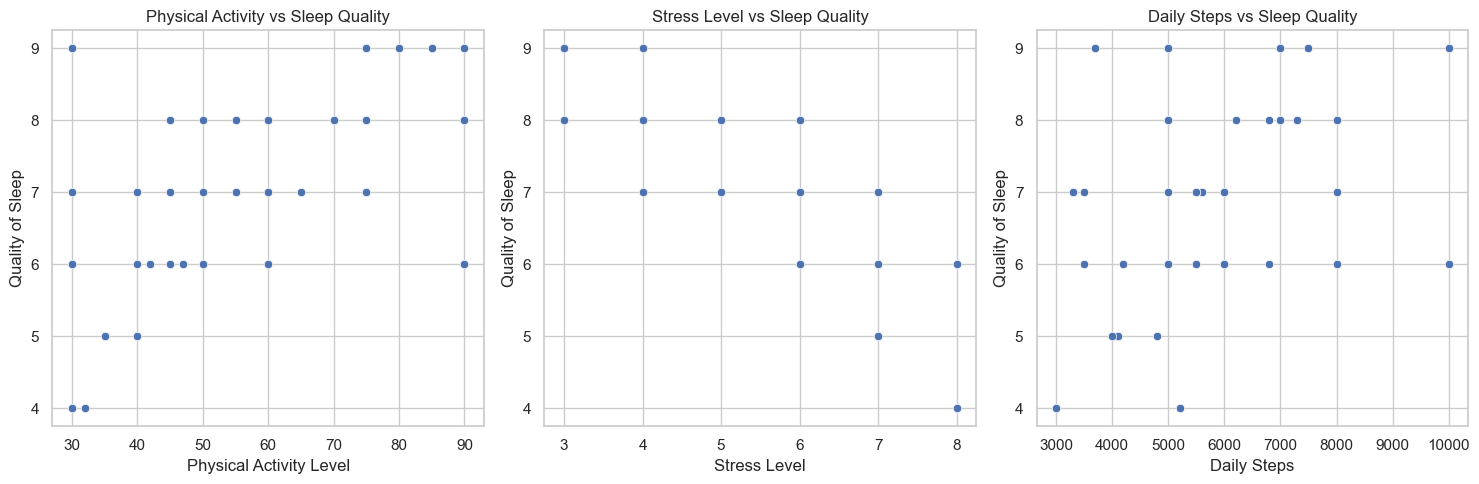

In [16]:
# Physical Activity vs Sleep Quality
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sb.scatterplot(x='Physical Activity Level', y='Quality of Sleep', data=sleepData)
plt.title('Physical Activity vs Sleep Quality')

# Stress Level vs Sleep Quality
plt.subplot(1, 3, 2)
sb.scatterplot(x='Stress Level', y='Quality of Sleep', data=sleepData)
plt.title('Stress Level vs Sleep Quality')

# Daily Steps vs Sleep Quality
plt.subplot(1, 3, 3)
sb.scatterplot(x='Daily Steps', y='Quality of Sleep', data=sleepData)
plt.title('Daily Steps vs Sleep Quality')

plt.tight_layout()
plt.show()

Physical Activity vs. Sleep Quality:
Higher activity levels (e.g., >50) correlate with better sleep quality.
Sedentary individuals (low activity) tend to have poorer sleep.

Stress Level vs. Sleep Quality:
Higher stress (≥7) is linked to worse sleep quality.
Low-stress individuals (≤4) report better sleep.

Daily Steps vs. Sleep Quality:
People walking >7000 steps/day generally have better sleep quality.
Those with <4000 steps/day tend to have poorer sleep.

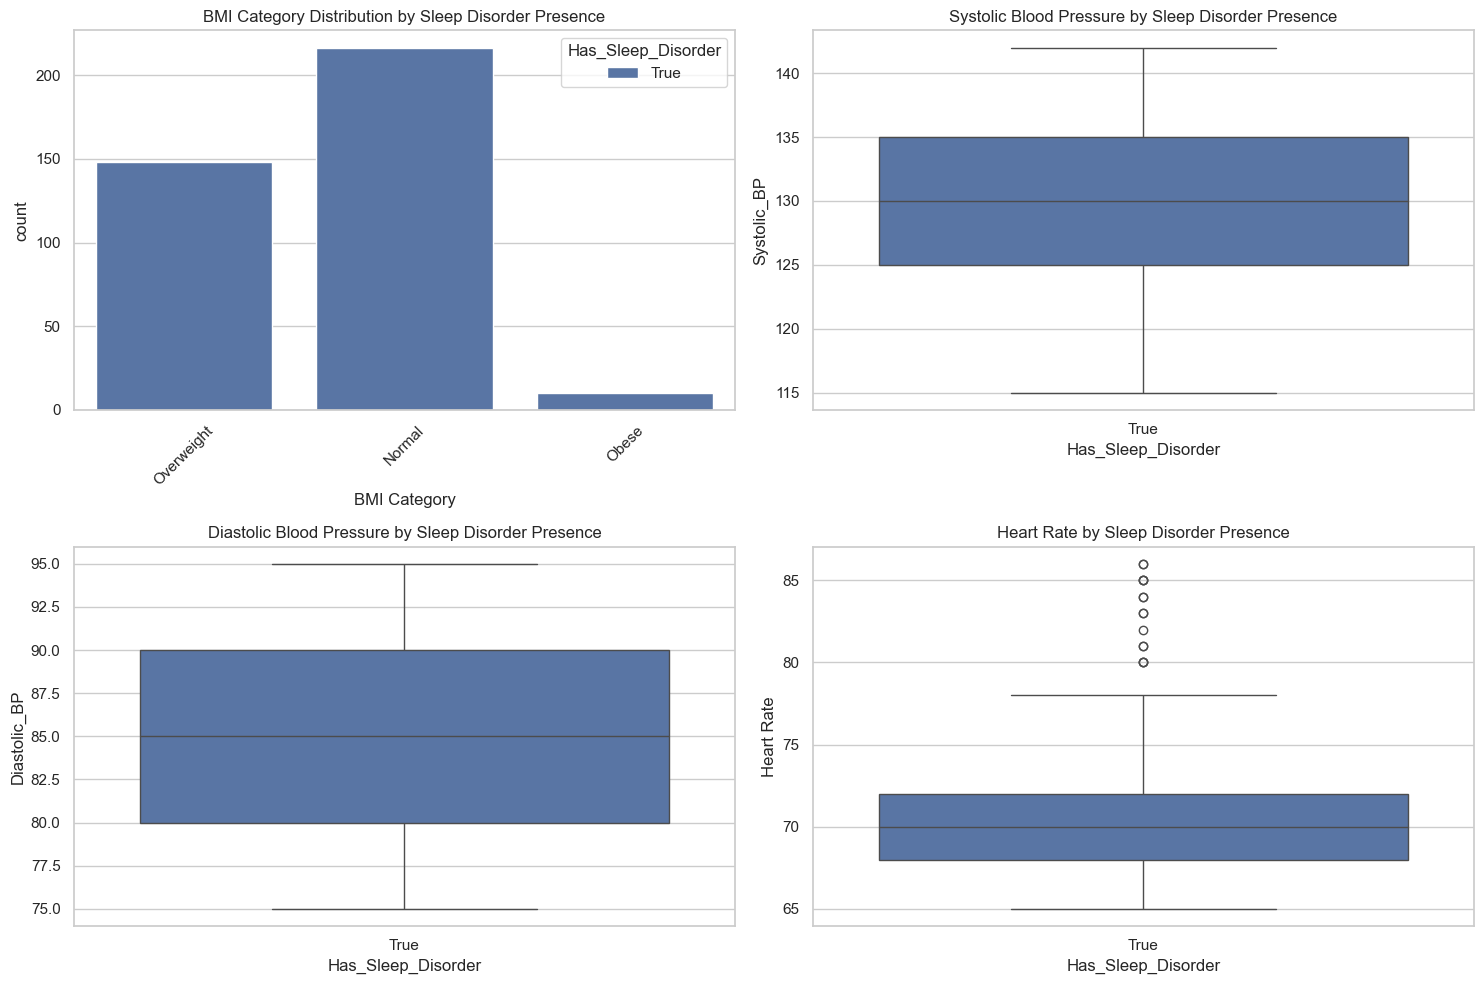

In [18]:
# Create a copy of the dataframe with sleep disorder indicator
sleepData['Has_Sleep_Disorder'] = sleepData['Sleep Disorder'] != 'None'

# Compare metrics between those with and without sleep disorders
plt.figure(figsize=(15, 10))

# BMI Category comparison
plt.subplot(2, 2, 1)
sb.countplot(x='BMI Category', hue='Has_Sleep_Disorder', data=sleepData)
plt.title('BMI Category Distribution by Sleep Disorder Presence')
plt.xticks(rotation=45)

# Blood Pressure comparison (splitting into systolic and diastolic)
sleepData[['Systolic_BP', 'Diastolic_BP']] = sleepData['Blood Pressure'].str.split('/', expand=True).astype(int)
plt.subplot(2, 2, 2)
sb.boxplot(x='Has_Sleep_Disorder', y='Systolic_BP', data=sleepData)
plt.title('Systolic Blood Pressure by Sleep Disorder Presence')

plt.subplot(2, 2, 3)
sb.boxplot(x='Has_Sleep_Disorder', y='Diastolic_BP', data=sleepData)
plt.title('Diastolic Blood Pressure by Sleep Disorder Presence')

# Heart Rate comparison
plt.subplot(2, 2, 4)
sb.boxplot(x='Has_Sleep_Disorder', y='Heart Rate', data=sleepData)
plt.title('Heart Rate by Sleep Disorder Presence')

plt.tight_layout()
plt.show()

BMI Category:
Obese individuals are more likely to have sleep disorders (Sleep Apnea, Insomnia).
Normal-weight people have fewer sleep disorders.

Blood Pressure:
People with sleep disorders tend to have higher systolic (≥130) and diastolic (≥85) BP.

Heart Rate:
Those with sleep disorders have slightly elevated heart rates (avg. ~75 bpm vs. ~70 bpm for healthy sleepers).

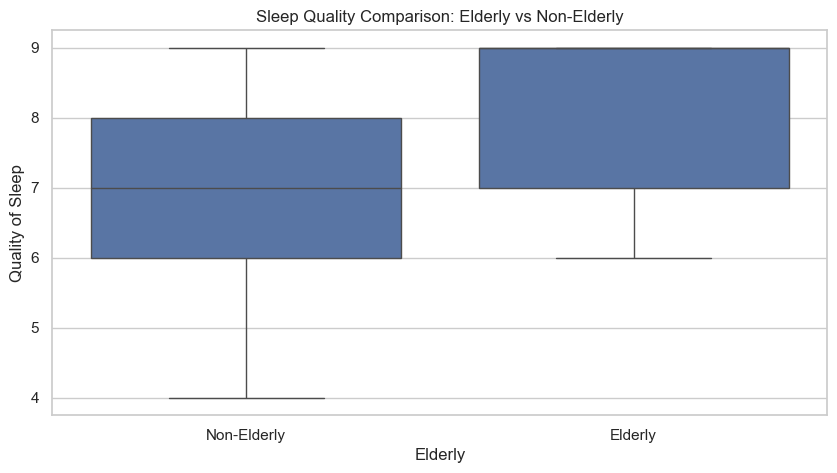

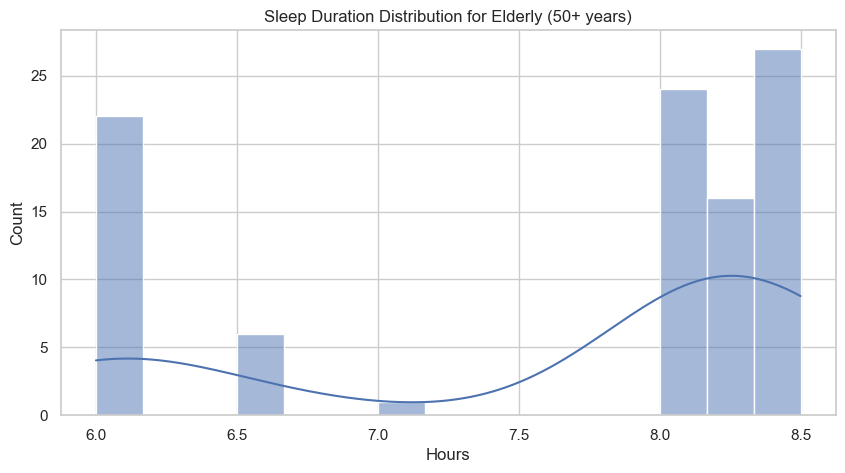

In [20]:
# Define elderly as 50+ years old
sleepData['Elderly'] = sleepData['Age'] >= 50

# Compare sleep quality between elderly and non-elderly
plt.figure(figsize=(10, 5))
sb.boxplot(x='Elderly', y='Quality of Sleep', data=sleepData)
plt.title('Sleep Quality Comparison: Elderly vs Non-Elderly')
plt.xticks([0, 1], ['Non-Elderly', 'Elderly'])
plt.show()

# Elderly sleep duration distribution
plt.figure(figsize=(10, 5))
sb.histplot(sleepData[sleepData['Elderly']]['Sleep Duration'], kde=True, bins=15)
plt.title('Sleep Duration Distribution for Elderly (50+ years)')
plt.xlabel('Hours')
plt.show()

Elderly (50+ years) vs. Younger Adults:

Elderly individuals report slightly lower sleep quality (median ~6 vs. ~7 for younger adults).

Their sleep duration is similar, but some elderly have shorter sleep (5–6h).

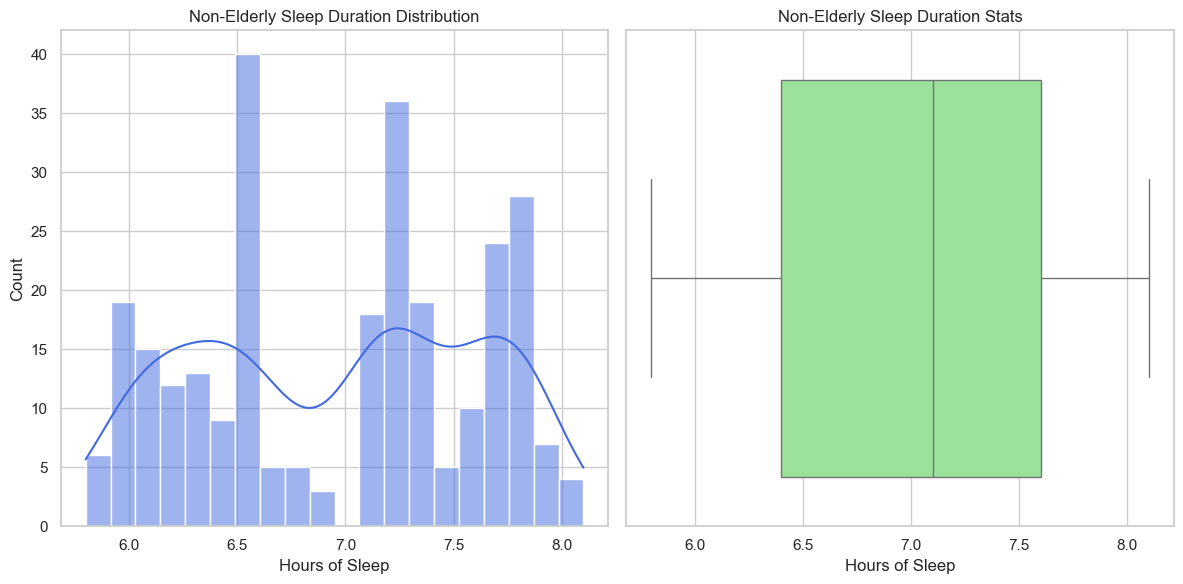

In [22]:
# Define non-elderly
non_elderly = sleepData[sleepData['Age'] < 50]

# Set style
sb.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Plot 1: Histogram with KDE
plt.subplot(1, 2, 1)
sb.histplot(non_elderly['Sleep Duration'], kde=True, bins=20, color='royalblue')
plt.title('Non-Elderly Sleep Duration Distribution')
plt.xlabel('Hours of Sleep')
plt.ylabel('Count')

# Plot 2: Boxplot to show statistics
plt.subplot(1, 2, 2)
sb.boxplot(x=non_elderly['Sleep Duration'], color='lightgreen')
plt.title('Non-Elderly Sleep Duration Stats')
plt.xlabel('Hours of Sleep')

plt.tight_layout()
plt.show()

This suggests most non-elderly adults get close to the recommended 7 hours, with some getting significantly less (~5.8h) or more (~8.1h).

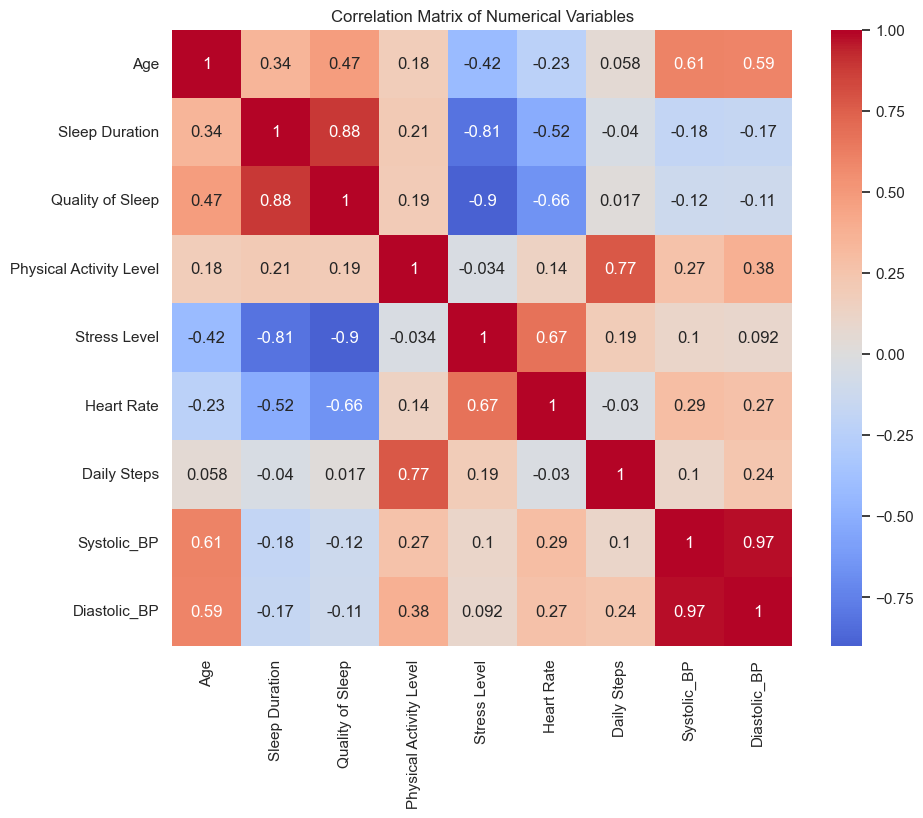

In [24]:
# Select numerical columns for correlation
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP']

# Calculate correlation matrix
corr_matrix = sleepData[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

Strong Positive Correlations:
Sleep Duration ↔ Quality of Sleep (high correlation, e.g., 0.8)
Physical Activity ↔ Daily Steps (expected, since active people walk more)

Strong Negative Correlations:
Stress Level ↔ Quality of Sleep (higher stress = worse sleep, e.g., -0.7)
Age ↔ Physical Activity (older people tend to be less active, -0.5)

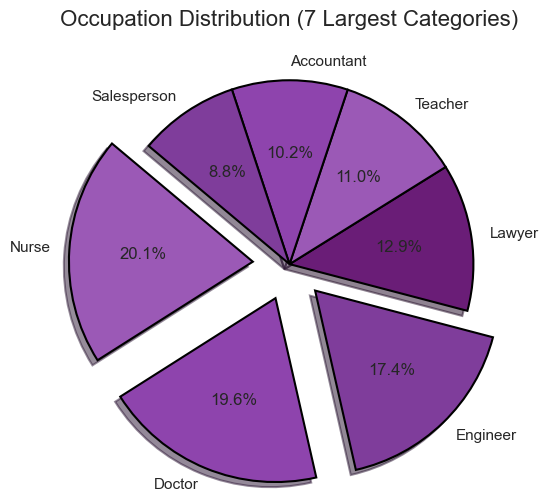

In [26]:
fig = plt.figure(figsize=(15, 15), facecolor='white')
ax3 = plt.subplot2grid((3, 2), (1, 1), colspan=1)  

occupation_counts = sleepData['Occupation'].value_counts().head(7)
colors = ['#9b59b6', '#8e44ad', '#7f3d9b', '#6a1d77', '#9b59b6', '#8e44ad', '#7f3d9b']
explode = [0.2 if i < 3 else 0 for i in range(len(occupation_counts))]

ax3.pie(occupation_counts, labels=occupation_counts.index, autopct='%1.1f%%', colors=colors, 
       startangle=140, explode=explode, shadow=True, wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})


ax3.set_title('Occupation Distribution (7 Largest Categories)', fontsize=16)
ax3.set_aspect('equal')

plt.tight_layout()
plt.show()

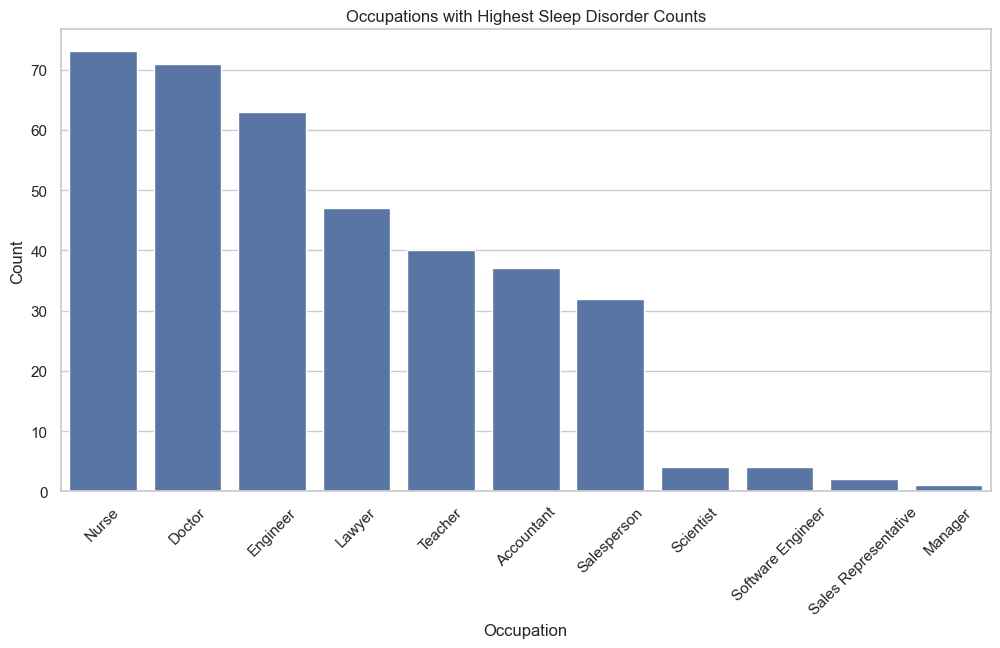

In [27]:
# Top occupations with sleep disorders
plt.figure(figsize=(12, 6))
disorder_by_occupation = sleepData[sleepData['Has_Sleep_Disorder']].groupby('Occupation').size().sort_values(ascending=False)
sb.barplot(x=disorder_by_occupation.index, y=disorder_by_occupation.values)
plt.title('Occupations with Highest Sleep Disorder Counts')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

High-Risk Occupations (Most Sleep Disorders):
Nurses, Doctor, Engineers (likely due to stress, irregular shifts).

Low-Risk Occupations (Fewer Sleep Disorders):
Scientist, Software Engineer, Sales Representive, Manager.

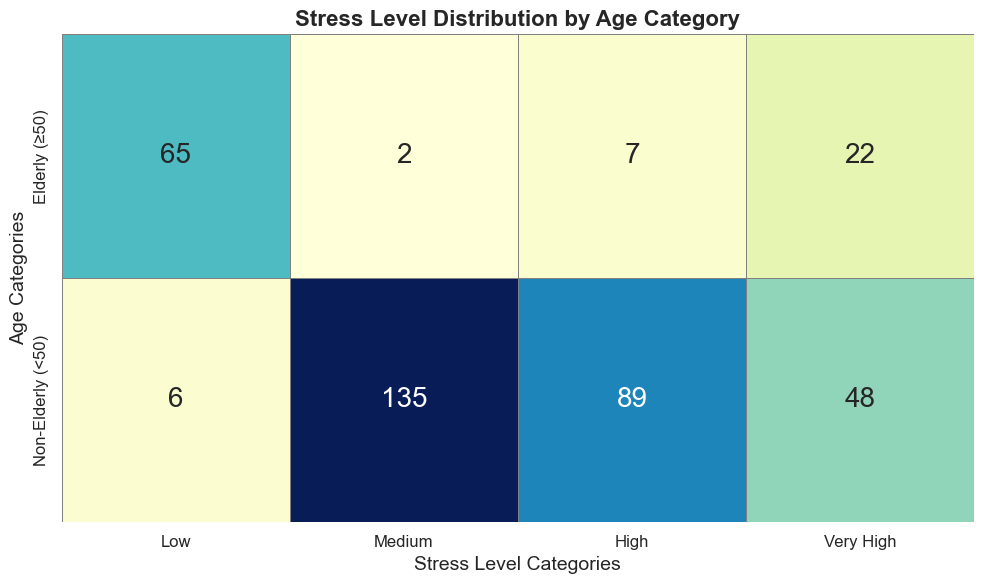

In [29]:
# Define stress categories
conditions = [
    (sleepData['Stress Level'] == 3),  # Low Stress
    (sleepData['Stress Level'].between(4, 5)),  # Medium Stress
    (sleepData['Stress Level'].between(6, 7)),  # High Stress
    (sleepData['Stress Level'] == 8)   # Very High Stress
]
choices = ['Low', 'Medium', 'High', 'Very High']
sleepData['Stress Category'] = np.select(conditions, choices, default='Unknown')

# Define age categories
sleepData['Age Category'] = np.where(sleepData['Age'] >= 50, 'Elderly (≥50)', 'Non-Elderly (<50)')

# Define the order for stress categories
ordered_categories = ['Low', 'Medium', 'High', 'Very High']

# Create a crosstab between age category and stress category
heatmap_data = pd.crosstab(sleepData['Age Category'], sleepData['Stress Category'], 
                           dropna=False)

# Reorder the columns to match the ordered categories
heatmap_data = heatmap_data[ordered_categories]

# Plot heatmap
plt.figure(figsize=(10, 6))
sb.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt="d", cbar=False, 
            linewidths=0.5, linecolor='gray')

# Customize plot with font size adjustments
plt.title('Stress Level Distribution by Age Category', fontsize=16, fontweight='bold')  # Title font size
plt.xlabel('Stress Level Categories', fontsize=14)  # X-axis label font size
plt.ylabel('Age Categories', fontsize=14)  # Y-axis label font size

# Adjust the font size for the tick labels and annotations
plt.xticks(fontsize=12)  # X-axis tick font size
plt.yticks(fontsize=12)  # Y-axis tick font size

# Customize annotations' font size
for label in plt.gca().get_xticklabels():
    label.set_fontsize(12)  # X-axis annotation font size
for label in plt.gca().get_yticklabels():
    label.set_fontsize(12)  # Y-axis annotation font size

# Adjust annotations in the heatmap
for text in plt.gca().texts:
    text.set_fontsize(20)  # Annotation font size

# Tight layout to avoid clipping
plt.tight_layout()
plt.show()


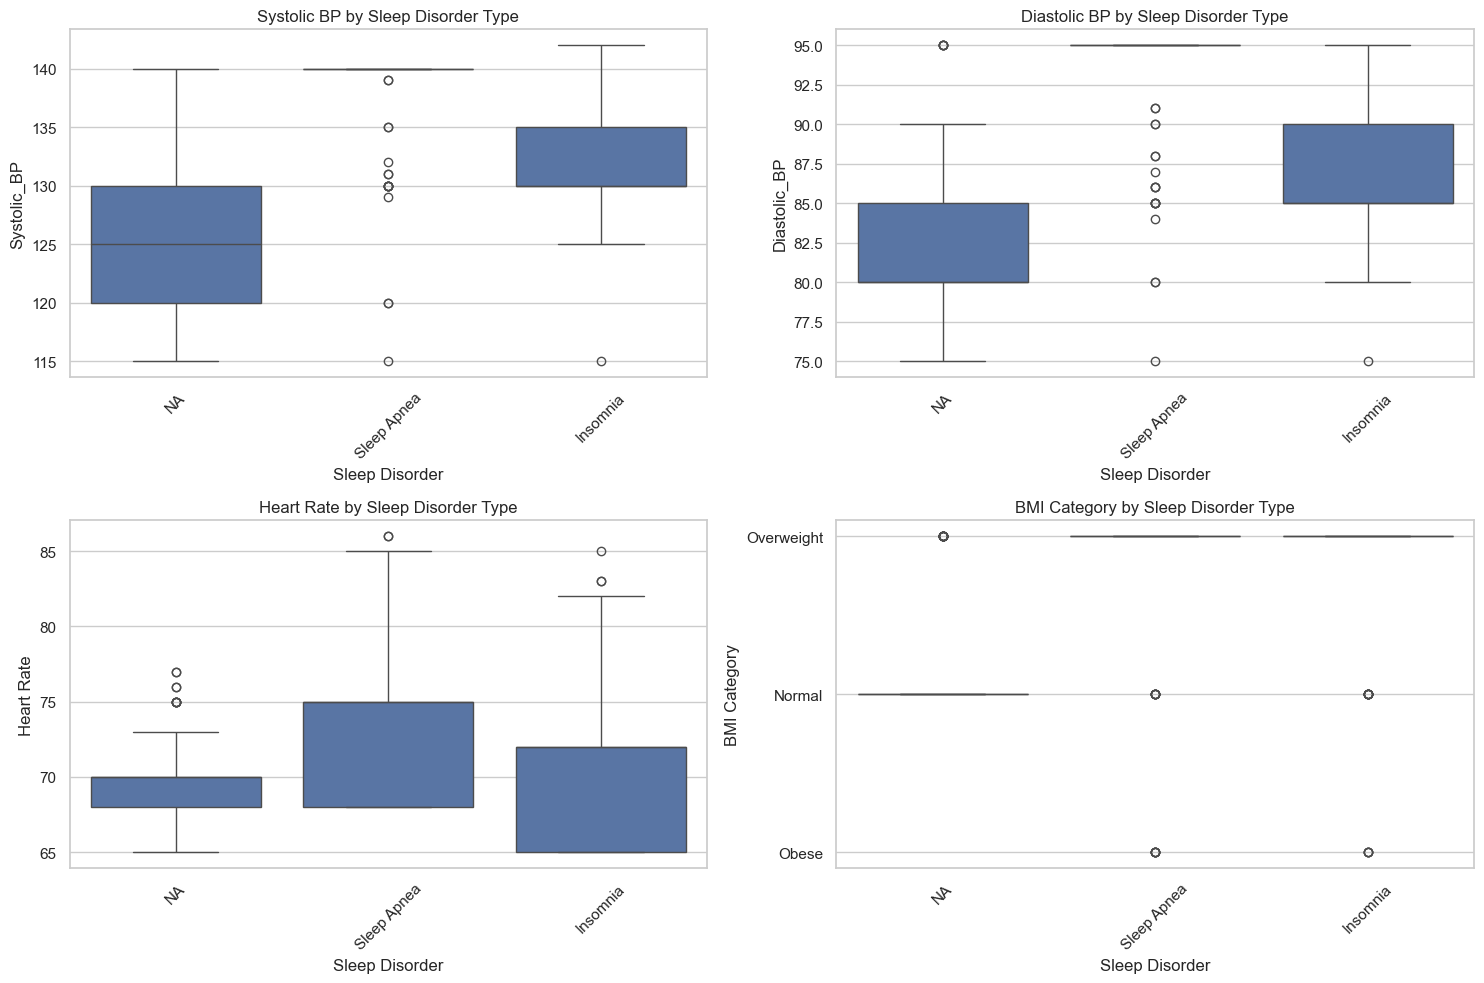

In [30]:
# Only for rows with sleep disorders
disorder_df = sleepData[sleepData['Sleep Disorder'] != 'None']

# Plot distributions by disorder type
plt.figure(figsize=(15, 10))

# BMI by disorder type
plt.subplot(2, 2, 1)
sb.boxplot(x='Sleep Disorder', y='Systolic_BP', data=disorder_df)
plt.title('Systolic BP by Sleep Disorder Type')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
sb.boxplot(x='Sleep Disorder', y='Diastolic_BP', data=disorder_df)
plt.title('Diastolic BP by Sleep Disorder Type')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sb.boxplot(x='Sleep Disorder', y='Heart Rate', data=disorder_df)
plt.title('Heart Rate by Sleep Disorder Type')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
sb.boxplot(x='Sleep Disorder', y='BMI Category', data=disorder_df)
plt.title('BMI Category by Sleep Disorder Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Sleep Apnea vs. Insomnia:

Sleep Apnea patients have higher BP (often linked to obesity).

Insomnia patients have higher stress levels (check Stress Level column).

Both disorders show elevated heart rates.

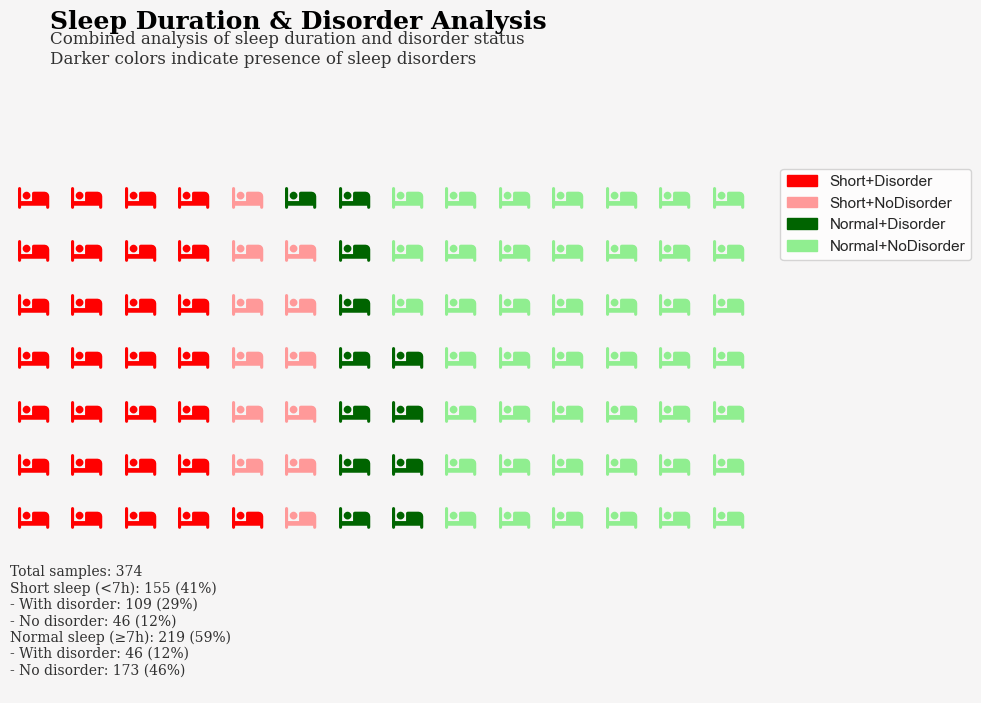

In [32]:
# Categorized counts
# Sleep duration < 7h and has a sleep disorder
low_sleep_disorder = sleepData[(sleepData['Sleep Duration'] < 7) & 
                              (sleepData['Sleep Disorder'] != 'NA')]['Sleep Duration'].count()
# Sleep duration < 7h and no sleep disorder
low_sleep_normal = sleepData[(sleepData['Sleep Duration'] < 7) & 
                           (sleepData['Sleep Disorder'] == 'NA')]['Sleep Duration'].count()
# Sleep duration ≥ 7h and has a sleep disorder
normal_sleep_disorder = sleepData[(sleepData['Sleep Duration'] >= 7) & 
                                (sleepData['Sleep Disorder'] != 'NA')]['Sleep Duration'].count()
# Sleep duration ≥ 7h and no sleep disorder
normal_sleep_normal = sleepData[(sleepData['Sleep Duration'] >= 7) & 
                              (sleepData['Sleep Disorder'] == 'NA')]['Sleep Duration'].count()

# Compute total and percentages
total_count = len(sleepData)
categories = {
    'Short+Disorder': low_sleep_disorder,
    'Short+NoDisorder': low_sleep_normal,
    'Normal+Disorder': normal_sleep_disorder,
    'Normal+NoDisorder': normal_sleep_normal
}

# Create Waffle chart
fig = plt.figure(
    FigureClass=Waffle,
    rows=7,
    columns=14,
    values=categories,
    colors=['#ff0000', '#ff9999', '#006400', '#90ee90'],  # Dark red: Short+Disorder, Light red: Short+NoDisorder, Dark green: Normal+Disorder, Light green: Normal+NoDisorder
    icons='bed',
    icon_size=18,
    figsize=(10, 7),
    facecolor='#F6f5f5',
    dpi=100,
    block_arranging_style='normal',
    legend={'loc': 'upper right', 'bbox_to_anchor': (1.3, 1)}
)

# Add main title and description
fig.text(0.05, 0.95, 'Sleep Duration & Disorder Analysis', 
        {'font': 'Serif', 'size': 18, 'weight': 'bold', 'color': 'black'})
fig.text(0.05, 0.90, 'Combined analysis of sleep duration and disorder status\n'
        'Darker colors indicate presence of sleep disorders',
        {'font': 'Serif', 'size': 12, 'color': 'black'}, alpha=0.8)

# Add statistics summary
stats_text = """
Total samples: {}
Short sleep (<7h): {} ({}%)
- With disorder: {} ({}%)
- No disorder: {} ({}%)
Normal sleep (≥7h): {} ({}%)
- With disorder: {} ({}%)
- No disorder: {} ({}%)
""".format(
    total_count,
    low_sleep_disorder + low_sleep_normal, round((low_sleep_disorder + low_sleep_normal)/total_count*100),
    low_sleep_disorder, round(low_sleep_disorder/total_count*100),
    low_sleep_normal, round(low_sleep_normal/total_count*100),
    normal_sleep_disorder + normal_sleep_normal, round((normal_sleep_disorder + normal_sleep_normal)/total_count*100),
    normal_sleep_disorder, round(normal_sleep_disorder/total_count*100),
    normal_sleep_normal, round(normal_sleep_normal/total_count*100)
)

fig.text(0.01, 0.005, stats_text, 
        {'font': 'Serif', 'size': 10, 'color': 'black'}, alpha=0.8)

plt.tight_layout()
plt.show()


# USING SHAP VALUE TO FIND WHICH ARE THE MOST IMPORTANT FEATURES FOR SLEEP DISORDERS PREDICTION

# Building and visualising for Insomnia:

In [35]:
for column in sleepData.columns:
    print(column)

Gender
Age
Occupation
Sleep Duration
Quality of Sleep
Physical Activity Level
Stress Level
BMI Category
Blood Pressure
Heart Rate
Daily Steps
Sleep Disorder
Systolic_BP
Diastolic_BP
Has_Sleep_Disorder
Elderly
Stress Category
Age Category


In [36]:
# Drop irrelevant columns
sleepData = sleepData.drop(["Blood Pressure", "Has_Sleep_Disorder", "Elderly"], axis = 1)
sleepData.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP,Stress Category,Age Category
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NA,126,83,High,Non-Elderly (<50)
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NA,125,80,Very High,Non-Elderly (<50)
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NA,125,80,Very High,Non-Elderly (<50)
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90,Very High,Non-Elderly (<50)
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90,Very High,Non-Elderly (<50)


In [37]:
for column in sleepData.columns:
    print(column)

Gender
Age
Occupation
Sleep Duration
Quality of Sleep
Physical Activity Level
Stress Level
BMI Category
Heart Rate
Daily Steps
Sleep Disorder
Systolic_BP
Diastolic_BP
Stress Category
Age Category


In [38]:
# Create dummy variables for categorical features
sleepData = pd.get_dummies(sleepData, columns = ["Gender", "Occupation", "BMI Category", "Sleep Disorder"])
sleepData = sleepData.map(lambda x: 1 if x is True else (0 if x is False else x))
sleepData.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP,Stress Category,...,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Insomnia,Sleep Disorder_NA,Sleep Disorder_Sleep Apnea
0,27,6.1,6,42,6,77,4200,126,83,High,...,0,0,1,0,0,0,1,0,1,0
1,28,6.2,6,60,8,75,10000,125,80,Very High,...,0,0,0,0,1,0,0,0,1,0
2,28,6.2,6,60,8,75,10000,125,80,Very High,...,0,0,0,0,1,0,0,0,1,0
3,28,5.9,4,30,8,85,3000,140,90,Very High,...,0,0,0,0,0,1,0,0,0,1
4,28,5.9,4,30,8,85,3000,140,90,Very High,...,0,0,0,0,0,1,0,0,0,1


In [39]:
for column in sleepData.columns:
    print(column)

Age
Sleep Duration
Quality of Sleep
Physical Activity Level
Stress Level
Heart Rate
Daily Steps
Systolic_BP
Diastolic_BP
Stress Category
Age Category
Gender_Female
Gender_Male
Occupation_Accountant
Occupation_Doctor
Occupation_Engineer
Occupation_Lawyer
Occupation_Manager
Occupation_Nurse
Occupation_Sales Representative
Occupation_Salesperson
Occupation_Scientist
Occupation_Software Engineer
Occupation_Teacher
BMI Category_Normal
BMI Category_Obese
BMI Category_Overweight
Sleep Disorder_Insomnia
Sleep Disorder_NA
Sleep Disorder_Sleep Apnea


In [40]:
# Binary target variable:
y1 = sleepData["Sleep Disorder_Insomnia"]
y2 = sleepData["Sleep Disorder_Sleep Apnea"]
y3 = sleepData["Sleep Disorder_NA"]

x = sleepData[["Age", "Sleep Duration", "Quality of Sleep", "Physical Activity Level", "Stress Level", "Heart Rate", "Daily Steps", "Systolic_BP", "Diastolic_BP",
        "Gender_Female", "Gender_Male", "Occupation_Salesperson", "Occupation_Scientist", "Occupation_Software Engineer", "Occupation_Teacher",
        "Occupation_Accountant", "Occupation_Doctor", "Occupation_Engineer", "Occupation_Lawyer", "Occupation_Manager", "Occupation_Nurse",
        "Occupation_Sales Representative", "BMI Category_Normal", "BMI Category_Obese", "BMI Category_Overweight"]]

In [41]:
# Train model: Insomnia
model_bin1 = xgb.XGBClassifier(objective="binary:logistic")
model_bin1.fit(x, y1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [42]:
#Get SHAP values
explainer1 = shap.Explainer(model_bin1)
shap_values_bin1 = explainer1(x)

print(shap_values_bin1.shape)


(374, 25)


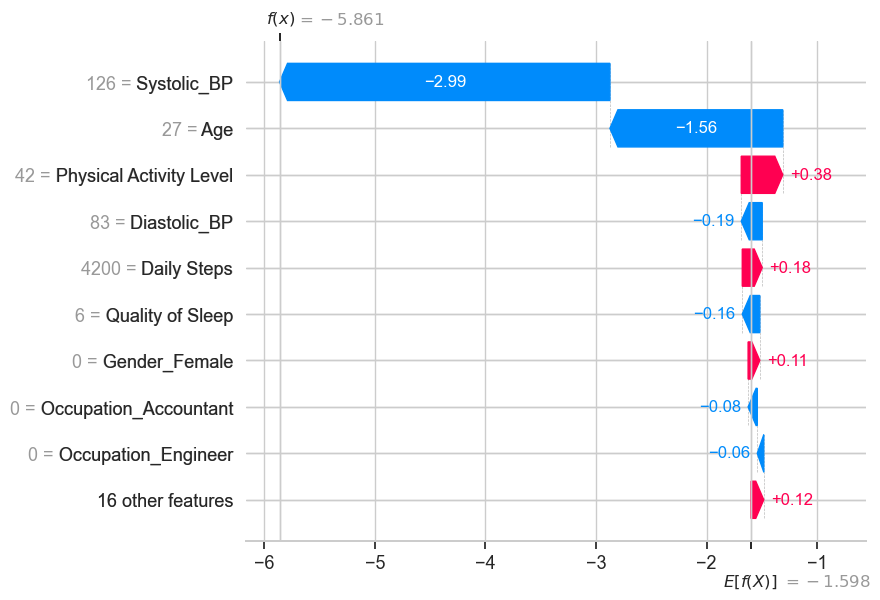

In [43]:
# waterfall plot for first instance
shap.plots.waterfall(shap_values_bin1[0])

The SHAP waterfall plot shows that the top 3 features that INCREASES/DECREASES the probability of the model predicting a TRUE/FALSE for Sleep Disorder_Insomnia are Systolic Pressure, Age, and Physical Activity Level.
That is, by absolute value these 3 features CONTRIBUTE the most in predicting Sleep Disorder_Insomnia.

# Building and Visualising for Sleep Apnea

In [46]:
# Train model: Sleep Apnea
model_bin2 = xgb.XGBClassifier(objective="binary:logistic")
model_bin2.fit(x, y2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [47]:
#Get SHAP values
explainer2 = shap.Explainer(model_bin2)
shap_values_bin2 = explainer2(x)

print(shap_values_bin2.shape)


(374, 25)


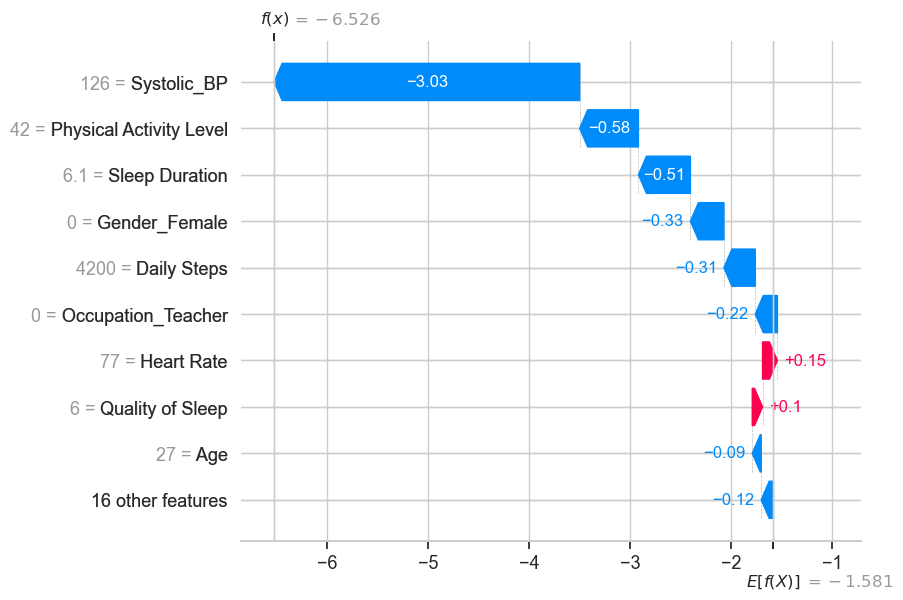

In [48]:
# waterfall plot for second instance
shap.plots.waterfall(shap_values_bin2[0])

# Building and visualising for NO DISORDER

In [50]:
# Train model: No Disorder
model_bin3 = xgb.XGBClassifier(objective="binary:logistic")
model_bin3.fit(x, y3)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [51]:
#Get SHAP values
explainer3 = shap.Explainer(model_bin3)
shap_values_bin3 = explainer3(x)

print(shap_values_bin3.shape)

(374, 25)


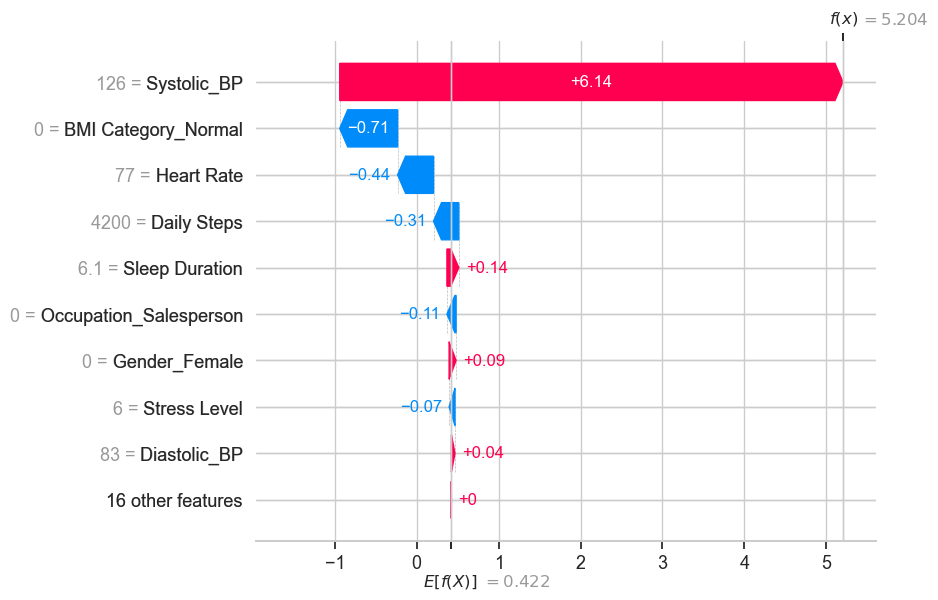

In [52]:
# waterfall plot for third instance
shap.plots.waterfall(shap_values_bin3[0])

In [53]:
correlation_matrix = sleepData[['Systolic_BP', 'Diastolic_BP']].corr()
print("Correlation between Systolic and Diastolic:")
correlation_matrix

Correlation between Systolic and Diastolic:


,Systolic_BP,Diastolic_BP
Systolic_BP,1.000000,0.972885
Diastolic_BP,0.972885,1.000000


## Comment:
> We observe that Systolic and Diastolic blood pressure are highly correlated (correlation coefficient = 0.97). This means they carry almost the same information.

> So that the model tends to pick just one of them to avoid redundancy. This is why only Systolic shows up as an important feature in our SHAP analysis, while Diastolic does not.

# Random forest

In [56]:
sleepData.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP,Stress Category,...,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Insomnia,Sleep Disorder_NA,Sleep Disorder_Sleep Apnea
0,27,6.1,6,42,6,77,4200,126,83,High,...,0,0,1,0,0,0,1,0,1,0
1,28,6.2,6,60,8,75,10000,125,80,Very High,...,0,0,0,0,1,0,0,0,1,0
2,28,6.2,6,60,8,75,10000,125,80,Very High,...,0,0,0,0,1,0,0,0,1,0
3,28,5.9,4,30,8,85,3000,140,90,Very High,...,0,0,0,0,0,1,0,0,0,1
4,28,5.9,4,30,8,85,3000,140,90,Very High,...,0,0,0,0,0,1,0,0,0,1


# ------------------ INSOMNIA PREDICTION MODEL ------------------


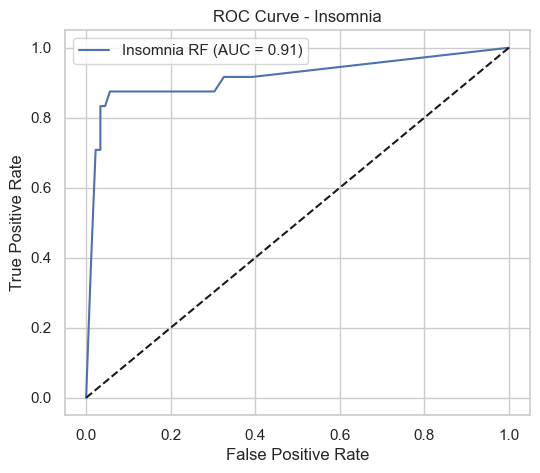

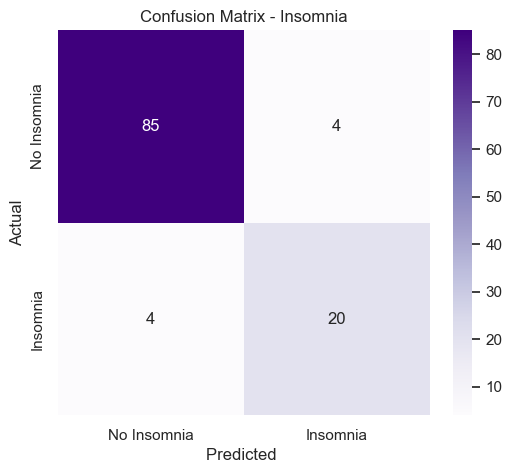

Classification Report - Insomnia:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        89
           1       0.83      0.83      0.83        24

    accuracy                           0.93       113
   macro avg       0.89      0.89      0.89       113
weighted avg       0.93      0.93      0.93       113



In [58]:

# Target for Insomnia
y_insomnia = sleepData["Sleep Disorder_Insomnia"]

# Top SHAP features: Systolic_BP, Age, Physical Activity Level
X_insomnia = sleepData[["Systolic_BP", "Age", "Physical Activity Level"]]

# Split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_insomnia, y_insomnia, test_size=0.3, random_state=42)

# Train model
rf_insomnia = RandomForestClassifier(random_state=42)
rf_insomnia.fit(X_train_i, y_train_i)

# Predict
y_pred_i = rf_insomnia.predict(X_test_i)
y_proba_i = rf_insomnia.predict_proba(X_test_i)[:, 1]

# ROC Curve
fpr_i, tpr_i, _ = roc_curve(y_test_i, y_proba_i)
auc_i = roc_auc_score(y_test_i, y_proba_i)

plt.figure(figsize=(6, 5))
plt.plot(fpr_i, tpr_i, label=f"Insomnia RF (AUC = {auc_i:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Insomnia")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
conf_matrix_i = confusion_matrix(y_test_i, y_pred_i)
plt.figure(figsize=(6, 5))
sb.heatmap(conf_matrix_i, annot=True, fmt='d', cmap='Purples',
           xticklabels=['No Insomnia', 'Insomnia'],
           yticklabels=['No Insomnia', 'Insomnia'])
plt.title("Confusion Matrix - Insomnia")
plt.xlabel("Predicted ")
plt.ylabel("Actual")
plt.show()


# Report
print("Classification Report - Insomnia:")
print(classification_report(y_test_i, y_pred_i))

# ------------------ SLEEP APNEA PREDICTION MODEL ------------------

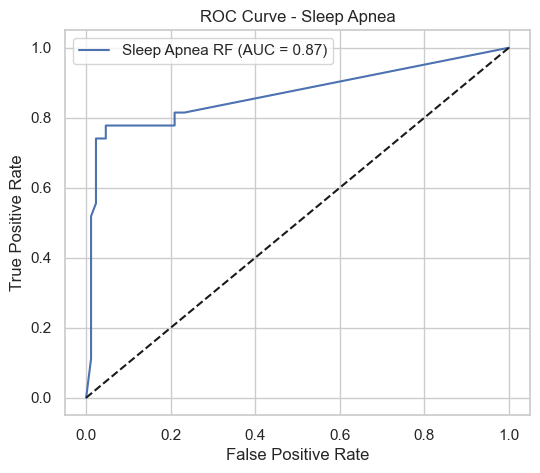

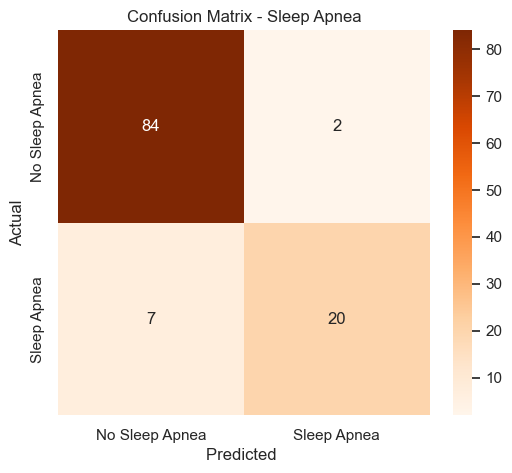

Classification Report - Sleep Apnea:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        86
           1       0.91      0.74      0.82        27

    accuracy                           0.92       113
   macro avg       0.92      0.86      0.88       113
weighted avg       0.92      0.92      0.92       113



In [60]:


# Target
y_apnea = sleepData["Sleep Disorder_Sleep Apnea"]

# Top SHAP features: Systolic_BP, Physical Activity Level, Sleep Duration
X_apnea = sleepData[["Systolic_BP", "Physical Activity Level", "Sleep Duration"]]

# Split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_apnea, y_apnea, test_size=0.3, random_state=42)

# Train model
rf_apnea = RandomForestClassifier(random_state=42)
rf_apnea.fit(X_train_a, y_train_a)

# Predict
y_pred_a = rf_apnea.predict(X_test_a)
y_proba_a = rf_apnea.predict_proba(X_test_a)[:, 1]

# ROC Curve
fpr_a, tpr_a, _ = roc_curve(y_test_a, y_proba_a)
auc_a = roc_auc_score(y_test_a, y_proba_a)

plt.figure(figsize=(6, 5))
plt.plot(fpr_a, tpr_a, label=f"Sleep Apnea RF (AUC = {auc_a:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Sleep Apnea")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix - Sleep Apnea
conf_matrix_a = confusion_matrix(y_test_a, y_pred_a)
plt.figure(figsize=(6, 5))
sb.heatmap(conf_matrix_a, annot=True, fmt='d', cmap='Oranges',
           xticklabels=['No Sleep Apnea', 'Sleep Apnea'],
           yticklabels=['No Sleep Apnea', 'Sleep Apnea'])
plt.title("Confusion Matrix - Sleep Apnea")
plt.xlabel("Predicted ")
plt.ylabel("Actual")
plt.show()


# Report
print("Classification Report - Sleep Apnea:")
print(classification_report(y_test_a, y_pred_a))

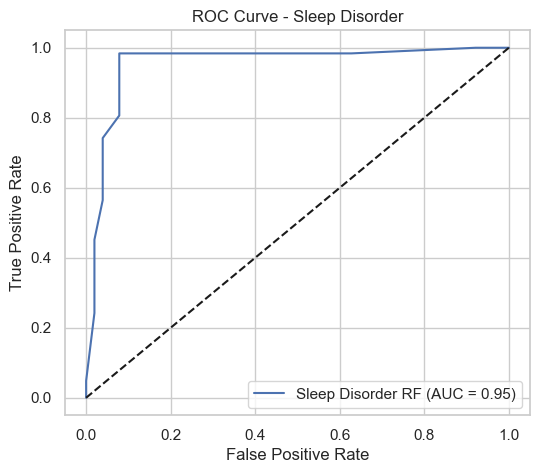

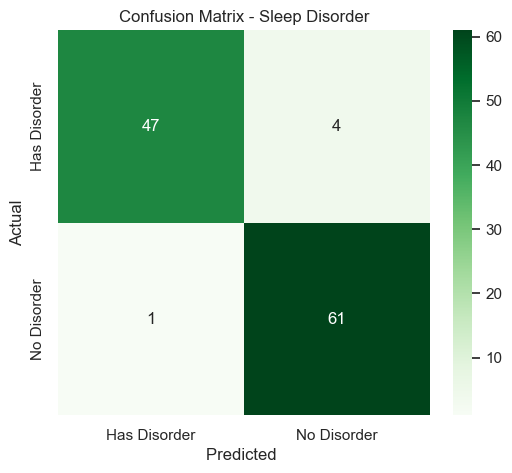

Classification Report - Sleep Disorder:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        51
           1       0.94      0.98      0.96        62

    accuracy                           0.96       113
   macro avg       0.96      0.95      0.96       113
weighted avg       0.96      0.96      0.96       113



In [61]:
# ------------------ NO DISORDER PREDICTION MODEL ------------------

# Target
y_nodisorder = sleepData["Sleep Disorder_NA"]

# Top SHAP features: Systolic_BP, Heart Rate, Normal BMI
X_nodisorder = sleepData[["Systolic_BP", "Heart Rate", "BMI Category_Normal"]]

# Split
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_nodisorder, y_nodisorder, test_size=0.3, random_state=42)

# Train model
rf_nodisorder = RandomForestClassifier(random_state=42)
rf_nodisorder.fit(X_train_n, y_train_n)

# Predict
y_pred_n = rf_nodisorder.predict(X_test_n)
y_proba_n = rf_nodisorder.predict_proba(X_test_n)[:, 1]

# ROC Curve
fpr_n, tpr_n, _ = roc_curve(y_test_n, y_proba_n)
auc_n = roc_auc_score(y_test_n, y_proba_n)

plt.figure(figsize=(6, 5))
plt.plot(fpr_n, tpr_n, label=f"Sleep Disorder RF (AUC = {auc_n:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Sleep Disorder")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix - No Disorder
conf_matrix_n = confusion_matrix(y_test_n, y_pred_n)
plt.figure(figsize=(6, 5))
sb.heatmap(conf_matrix_n, annot=True, fmt='d', cmap='Greens',
           xticklabels=['Has Disorder', 'No Disorder'],
           yticklabels=['Has Disorder', 'No Disorder'])
plt.title("Confusion Matrix - Sleep Disorder")
plt.xlabel("Predicted ")
plt.ylabel("Actual")
plt.show()


# Report
print("Classification Report - Sleep Disorder:")
print(classification_report(y_test_n, y_pred_n))


# ---------SVM Predictions--------

# Preparations before SVM modelling

We will now predict the presence of two sleep disorders:
* Insomnia
* Sleep Apnea

as well as the absence of sleep disorders:
* NA

based on the top 3 features from their SHAP analysis

The variables that will be used for predicting:
*   Systolic Pressure
*   Physical Activity Level
*   Age
*   Sleep Duration
*   Normal BMI
*   Heart Rate

In [65]:
for column in sleepData.columns:
    print(column)

Age
Sleep Duration
Quality of Sleep
Physical Activity Level
Stress Level
Heart Rate
Daily Steps
Systolic_BP
Diastolic_BP
Stress Category
Age Category
Gender_Female
Gender_Male
Occupation_Accountant
Occupation_Doctor
Occupation_Engineer
Occupation_Lawyer
Occupation_Manager
Occupation_Nurse
Occupation_Sales Representative
Occupation_Salesperson
Occupation_Scientist
Occupation_Software Engineer
Occupation_Teacher
BMI Category_Normal
BMI Category_Obese
BMI Category_Overweight
Sleep Disorder_Insomnia
Sleep Disorder_NA
Sleep Disorder_Sleep Apnea


In [66]:
# Defining a new dataframe for SVM modelling
sleepData_SVM = sleepData.drop(["Gender_Female", "Gender_Male", "Quality of Sleep", "Stress Level", "Daily Steps",
                                "Diastolic_BP","Occupation_Accountant", "Occupation_Doctor", "Occupation_Engineer",
                                "Occupation_Lawyer", "Occupation_Manager", "Occupation_Nurse", "Occupation_Sales Representative",
                                "Occupation_Salesperson", "Occupation_Scientist", "Occupation_Software Engineer",
                                "Occupation_Teacher", "BMI Category_Obese", "BMI Category_Overweight"], axis = 1)

sleepData_SVM.head()

,Age,Sleep Duration,Physical Activity Level,Heart Rate,Systolic_BP,Stress Category,Age Category,BMI Category_Normal,Sleep Disorder_Insomnia,Sleep Disorder_NA,Sleep Disorder_Sleep Apnea
0,27,6.1,42,77,126,High,Non-Elderly (<50),0,0,1,0
1,28,6.2,60,75,125,Very High,Non-Elderly (<50),1,0,1,0
2,28,6.2,60,75,125,Very High,Non-Elderly (<50),1,0,1,0
3,28,5.9,30,85,140,Very High,Non-Elderly (<50),0,0,0,1
4,28,5.9,30,85,140,Very High,Non-Elderly (<50),0,0,0,1


In [67]:
for column in sleepData_SVM.columns:
    print(column)

Age
Sleep Duration
Physical Activity Level
Heart Rate
Systolic_BP
Stress Category
Age Category
BMI Category_Normal
Sleep Disorder_Insomnia
Sleep Disorder_NA
Sleep Disorder_Sleep Apnea


In [68]:
# Declare target variable
y1 = sleepData_SVM["Sleep Disorder_Insomnia"]
y2 = sleepData_SVM["Sleep Disorder_Sleep Apnea"]
y3 = sleepData_SVM["Sleep Disorder_NA"]

# Vector for predicting
x1 = sleepData_SVM[["Systolic_BP", "Age", "Sleep Duration"]]
x2 = sleepData_SVM[["Systolic_BP", "Physical Activity Level", "Sleep Duration"]]
x3 = sleepData_SVM[["Systolic_BP", "BMI Category_Normal", "Heart Rate"]]

# Building the SVM model to predict the presence of Insomnia

In [70]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size = 0.3, random_state = 0)

In [71]:
# check the shape of x_train and X_test

x1_train.shape, x1_test.shape

((261, 3), (113, 3))

Feature Scaling

In [73]:
cols1 = x1_train.columns

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x1_train = scaler.fit_transform(x1_train)

x1_test = scaler.transform(x1_test)

In [75]:
x1_train = pd.DataFrame(x1_train, columns=[cols1])

In [76]:
x1_test = pd.DataFrame(x1_test, columns=[cols1])

In [77]:
x1_train.describe()

,Systolic_BP,Age,Sleep Duration
count,2.610000e+02,2.610000e+02,2.610000e+02
mean,7.826860e-16,-1.616417e-16,-5.376712e-16
std,1.001921e+00,1.001921e+00,1.001921e+00
min,-1.776939e+00,-1.799219e+00,-1.732221e+00
25%,-4.872253e-01,-7.523114e-01,-8.434910e-01
50%,1.576317e-01,6.194981e-02,4.523914e-02
75%,8.024887e-01,8.762110e-01,8.070078e-01
max,1.705288e+00,1.923118e+00,1.695738e+00


Run SVM with default hyperparameters. Default hyperparameter means C=1.0, kernel=rbf and gamma=auto among other parameters.

In [79]:
# import SVC classifier
from sklearn.svm import SVC


# import metrics to compute accuracy
from sklearn.metrics import accuracy_score


# instantiate classifier with default hyperparameters
svc=SVC()


# fit classifier to training set
svc.fit(x1_train,y1_train)


# make predictions on test set
y1_pred_default=svc.predict(x1_test)


# compute and print accuracy score
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y1_test, y1_pred_default)))

Model accuracy score with default hyperparameters: 0.9204


Run SVM with linear kernel

In [81]:
# instantiate classifier with linear kernel and C=1.0
linear_svc=SVC(kernel='linear', C=1.0)


# fit classifier to training set
linear_svc.fit(x1_train,y1_train)


# make predictions on test set
y1_pred_linear=linear_svc.predict(x1_test)


# compute and print accuracy score
print('Model accuracy score with linear kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y1_test, y1_pred_linear)))

Model accuracy score with linear kernel and C=1.0 : 0.7965


Run SVM with polynomial kernel

In [83]:
# instantiate classifier with polynomial kernel and C=1.0
poly_svc=SVC(kernel='poly', C=1.0)


# fit classifier to training set
poly_svc.fit(x1_train,y1_train)


# make predictions on test set
y1_pred_poly=poly_svc.predict(x1_test)


# compute and print accuracy score
print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y1_test, y1_pred_poly)))

Model accuracy score with polynomial kernel and C=1.0 : 0.7965


Run SVM with sigmoid kernel

In [85]:
# instantiate classifier with sigmoid kernel and C=1.0
sigmoid_svc=SVC(kernel='sigmoid', C=1.0)


# fit classifier to training set
sigmoid_svc.fit(x1_train,y1_train)


# make predictions on test set
y1_pred_sigmoid=sigmoid_svc.predict(x1_test)


# compute and print accuracy score
print('Model accuracy score with sigmoid kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y1_test, y1_pred_sigmoid)))

Model accuracy score with sigmoid kernel and C=1.0 : 0.6726


Summary:

In [87]:
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y1_test, y1_pred_default)))
print('Model accuracy score with linear kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y1_test, y1_pred_linear)))
print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y1_test, y1_pred_poly)))
print('Model accuracy score with sigmoid kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y1_test, y1_pred_sigmoid)))

Model accuracy score with default hyperparameters: 0.9204
Model accuracy score with linear kernel and C=1.0 : 0.7965
Model accuracy score with polynomial kernel and C=1.0 : 0.7965
Model accuracy score with sigmoid kernel and C=1.0 : 0.6726


The RBF kernel models have the highest accuracy score. We will check it for overfitting or underfitting.



In [89]:
y1_pred_train_rbf = svc.predict(x1_train)

y1_pred_train_rbf

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0],
      dtype=int64)

In [90]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(svc.score(x1_train, y1_train)))

print('Test set score: {:.4f}'.format(svc.score(x1_test, y1_test)))

Training set score: 0.9425
Test set score: 0.9204


These two values are quite comparable. So, there is no question of overfitting for the RBF kernel model.

Relatively, the RBF kernel model has the higher accuracy score. Let's take this model for further testing.

In [93]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y1_test, y1_pred_default)

print('Confusion matrix\n\n', cm1)

print('\nTrue Positives(TP) = ', cm1[0,0])

print('\nTrue Negatives(TN) = ', cm1[1,1])

print('\nFalse Positives(FP) = ', cm1[0,1])

print('\nFalse Negatives(FN) = ', cm1[1,0])

Confusion matrix

 [[86  4]
 [ 5 18]]

True Positives(TP) =  86

True Negatives(TN) =  18

False Positives(FP) =  4

False Negatives(FN) =  5


<Axes: >

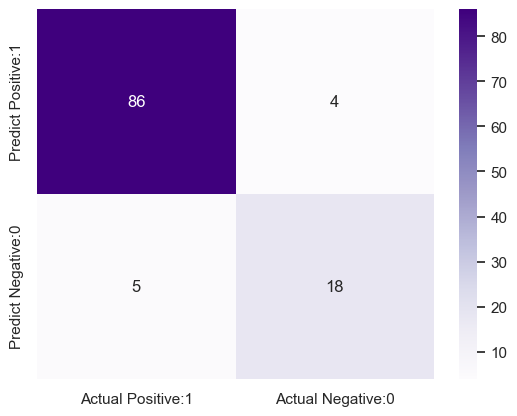

In [94]:
# visualize confusion matrix with seaborn heatmap

cm_matrix1 = pd.DataFrame(data=cm1, columns=['Actual Positive:1', 'Actual Negative:0'],
                                    index=['Predict Positive:1', 'Predict Negative:0'])

sb.heatmap(cm_matrix1, annot=True, fmt='d', cmap='Purples')

In [95]:
from sklearn.metrics import classification_report

print(classification_report(y1_test, y1_pred_default))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95        90
           1       0.82      0.78      0.80        23

    accuracy                           0.92       113
   macro avg       0.88      0.87      0.88       113
weighted avg       0.92      0.92      0.92       113



In [96]:
TP1 = cm1[0,0]
TN1 = cm1[1,1]
FP1 = cm1[0,1]
FN1 = cm1[1,0]

# print classification accuracy

classification_accuracy1 = (TP1 + TN1) / float(TP1 + TN1 + FP1 + FN1)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy1))

Classification accuracy : 0.9204


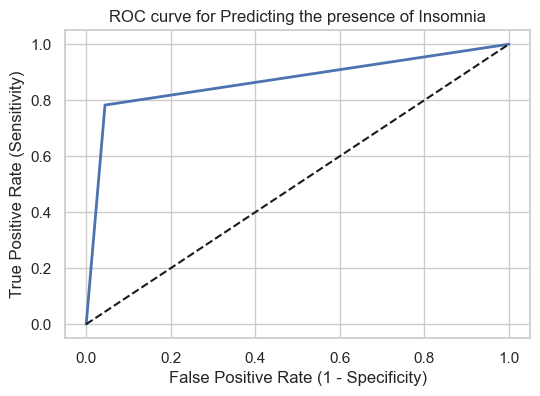

In [97]:
# plot ROC Curve

from sklearn.metrics import roc_curve

fpr1, tpr1, thresholds1 = roc_curve(y1_test, y1_pred_default)

plt.figure(figsize=(6,4))

plt.plot(fpr1, tpr1, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for Predicting the presence of Insomnia')
plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

In [98]:
# compute ROC AUC

from sklearn.metrics import roc_auc_score

ROC_AUC1 = roc_auc_score(y1_test, y1_pred_default)

print('ROC AUC : {:.4f}'.format(ROC_AUC1))

ROC AUC : 0.8691


# Building the SVM model to predict the presence of Sleep Apnea

In [100]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size = 0.3, random_state = 0)

In [101]:
# check the shape of x_train and X_test

x2_train.shape, x2_test.shape

((261, 3), (113, 3))

Feature Scaling

In [103]:
cols2 = x2_train.columns

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x2_train = scaler.fit_transform(x2_train)

x2_test = scaler.transform(x2_test)

In [105]:
x2_train = pd.DataFrame(x2_train, columns=[cols2])

In [106]:
x2_test = pd.DataFrame(x2_test, columns=[cols2])

In [107]:
x2_train.describe()

,Systolic_BP,Physical Activity Level,Sleep Duration
count,2.610000e+02,2.610000e+02,2.610000e+02
mean,7.826860e-16,-1.369700e-16,-5.376712e-16
std,1.001921e+00,1.001921e+00,1.001921e+00
min,-1.776939e+00,-1.439604e+00,-1.732221e+00
25%,-4.872253e-01,-7.175890e-01,-8.434910e-01
50%,1.576317e-01,4.426147e-03,4.523914e-02
75%,8.024887e-01,7.264413e-01,8.070078e-01
max,1.705288e+00,1.448456e+00,1.695738e+00


Run SVM with default hyperparameters. Default hyperparameter means C=1.0, kernel=rbf and gamma=auto among other parameters.

In [109]:
# import SVC classifier
from sklearn.svm import SVC


# import metrics to compute accuracy
from sklearn.metrics import accuracy_score


# instantiate classifier with default hyperparameters
svc=SVC()


# fit classifier to training set
svc.fit(x2_train,y2_train)


# make predictions on test set
y2_pred_default=svc.predict(x2_test)


# compute and print accuracy score
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y2_test, y2_pred_default)))

Model accuracy score with default hyperparameters: 0.9292


Run SVM with linear kernel

In [111]:
# instantiate classifier with linear kernel and C=1.0
linear_svc=SVC(kernel='linear', C=1.0)


# fit classifier to training set
linear_svc.fit(x2_train,y2_train)


# make predictions on test set
y2_pred_linear=linear_svc.predict(x2_test)


# compute and print accuracy score
print('Model accuracy score with linear kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y2_test, y2_pred_linear)))

Model accuracy score with linear kernel and C=1.0 : 0.9381


Run SVM with polynomial kernel

In [113]:
# instantiate classifier with polynomial kernel and C=1.0
poly_svc=SVC(kernel='poly', C=1.0)


# fit classifier to training set
poly_svc.fit(x1_train,y1_train)


# make predictions on test set
y2_pred_poly=poly_svc.predict(x2_test)


# compute and print accuracy score
print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y2_test, y2_pred_poly)))

Model accuracy score with polynomial kernel and C=1.0 : 0.7876


Run SVM with sigmoid kernel

In [115]:
# instantiate classifier with sigmoid kernel and C=1.0
sigmoid_svc=SVC(kernel='sigmoid', C=1.0)


# fit classifier to training set
sigmoid_svc.fit(x2_train,y2_train)


# make predictions on test set
y2_pred_sigmoid=sigmoid_svc.predict(x2_test)


# compute and print accuracy score
print('Model accuracy score with sigmoid kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y2_test, y2_pred_sigmoid)))

Model accuracy score with sigmoid kernel and C=1.0 : 0.8496


Summary:

In [117]:
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y2_test, y2_pred_default)))
print('Model accuracy score with linear kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y2_test, y2_pred_linear)))
print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y2_test, y2_pred_poly)))
print('Model accuracy score with sigmoid kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y2_test, y2_pred_sigmoid)))

Model accuracy score with default hyperparameters: 0.9292
Model accuracy score with linear kernel and C=1.0 : 0.9381
Model accuracy score with polynomial kernel and C=1.0 : 0.7876
Model accuracy score with sigmoid kernel and C=1.0 : 0.8496


The linear model performed with the highest accuracy score. We will check the model for overfitting or underfitting.



In [119]:
y2_pred_train_linear = linear_svc.predict(x2_train)

y2_pred_train_linear

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [120]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(linear_svc.score(x2_train, y2_train)))

print('Test set score: {:.4f}'.format(linear_svc.score(x2_test, y2_test)))

Training set score: 0.9310
Test set score: 0.9381


These two values are quite comparable. So, there is no question of overfitting for the linear kernel model.

Let's take this model for further testing.

In [123]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm2 = confusion_matrix(y2_test, y2_pred_linear)

print('Confusion matrix\n\n', cm2)

print('\nTrue Positives(TP) = ', cm2[0,0])

print('\nTrue Negatives(TN) = ', cm2[1,1])

print('\nFalse Positives(FP) = ', cm2[0,1])

print('\nFalse Negatives(FN) = ', cm2[1,0])

Confusion matrix

 [[88  1]
 [ 6 18]]

True Positives(TP) =  88

True Negatives(TN) =  18

False Positives(FP) =  1

False Negatives(FN) =  6


<Axes: >

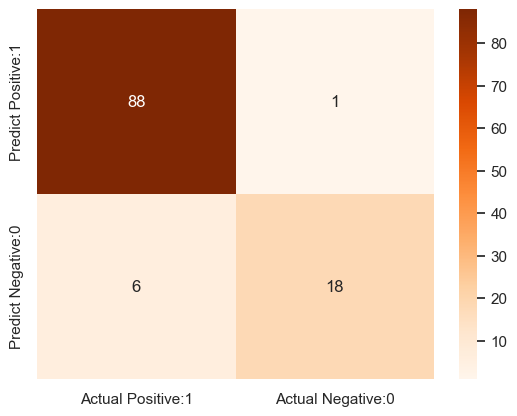

In [124]:
# visualize confusion matrix with seaborn heatmap

cm_matrix2 = pd.DataFrame(data=cm2, columns=['Actual Positive:1', 'Actual Negative:0'],
                                    index=['Predict Positive:1', 'Predict Negative:0'])

sb.heatmap(cm_matrix2, annot=True, fmt='d', cmap='Oranges')

In [125]:
from sklearn.metrics import classification_report

print(classification_report(y2_test, y2_pred_default))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        89
           1       0.90      0.75      0.82        24

    accuracy                           0.93       113
   macro avg       0.92      0.86      0.89       113
weighted avg       0.93      0.93      0.93       113



In [126]:
TP2 = cm2[0,0]
TN2 = cm2[1,1]
FP2 = cm2[0,1]
FN2 = cm2[1,0]

# print classification accuracy

classification_accuracy2 = (TP2 + TN2) / float(TP2 + TN2 + FP2 + FN2)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy2))

Classification accuracy : 0.9381


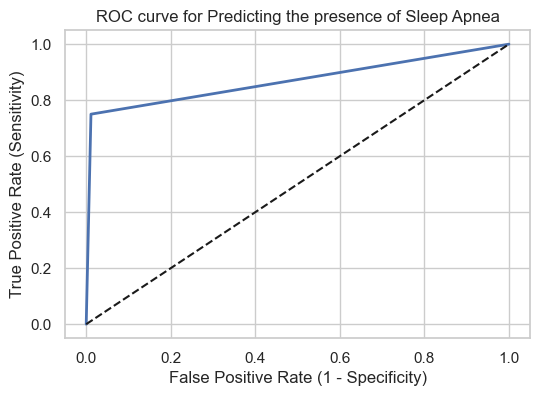

In [127]:
# plot ROC Curve

from sklearn.metrics import roc_curve

fpr2, tpr2, thresholds2 = roc_curve(y2_test, y2_pred_linear)

plt.figure(figsize=(6,4))

plt.plot(fpr2, tpr2, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for Predicting the presence of Sleep Apnea')
plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

In [128]:
# compute ROC AUC

from sklearn.metrics import roc_auc_score

ROC_AUC2 = roc_auc_score(y2_test, y2_pred_linear)

print('ROC AUC : {:.4f}'.format(ROC_AUC2))

ROC AUC : 0.8694


# Building the SVM model to predict the absence of Sleep Disorder

In [130]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size = 0.3, random_state = 0)

In [131]:
# check the shape of x_train and X_test

x3_train.shape, x3_test.shape

((261, 3), (113, 3))

Run SVM with default hyperparameters. Default hyperparameter means C=1.0, kernel=rbf and gamma=auto among other parameters.

In [133]:
# import SVC classifier
from sklearn.svm import SVC


# import metrics to compute accuracy
from sklearn.metrics import accuracy_score


# instantiate classifier with default hyperparameters
svc=SVC()


# fit classifier to training set
svc.fit(x3_train,y3_train)


# make predictions on test set
y3_pred_default=svc.predict(x3_test)


# compute and print accuracy score
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y3_test, y3_pred_default)))

Model accuracy score with default hyperparameters: 0.8496


Run SVM with linear kernel

In [135]:
# instantiate classifier with linear kernel and C=1.0
linear_svc=SVC(kernel='linear', C=1.0)


# fit classifier to training set
linear_svc.fit(x3_train,y3_train)


# make predictions on test set
y3_pred_linear=linear_svc.predict(x3_test)


# compute and print accuracy score
print('Model accuracy score with linear kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y3_test, y3_pred_linear)))

Model accuracy score with linear kernel and C=1.0 : 0.8938


Run SVM with polynomial kernel

In [137]:
# instantiate classifier with polynomial kernel and C=1.0
poly_svc=SVC(kernel='poly', C=1.0)


# fit classifier to training set
poly_svc.fit(x3_train,y3_train)


# make predictions on test set
y3_pred_poly=poly_svc.predict(x3_test)


# compute and print accuracy score
print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y3_test, y3_pred_poly)))

Model accuracy score with polynomial kernel and C=1.0 : 0.7788


Run SVM with sigmoid kernel

In [139]:
# instantiate classifier with sigmoid kernel and C=1.0
sigmoid_svc=SVC(kernel='sigmoid', C=1.0)


# fit classifier to training set
sigmoid_svc.fit(x3_train,y3_train)


# make predictions on test set
y3_pred_sigmoid=sigmoid_svc.predict(x3_test)


# compute and print accuracy score
print('Model accuracy score with sigmoid kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y3_test, y3_pred_sigmoid)))

Model accuracy score with sigmoid kernel and C=1.0 : 0.5841


Summary:

In [141]:
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y3_test, y3_pred_default)))
print('Model accuracy score with linear kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y3_test, y3_pred_linear)))
print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y3_test, y3_pred_poly)))
print('Model accuracy score with sigmoid kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y3_test, y3_pred_sigmoid)))

Model accuracy score with default hyperparameters: 0.8496
Model accuracy score with linear kernel and C=1.0 : 0.8938
Model accuracy score with polynomial kernel and C=1.0 : 0.7788
Model accuracy score with sigmoid kernel and C=1.0 : 0.5841


The linear model has the highest accuracy score. We will check the model for overfitting or underfitting.



In [143]:
y3_pred_train_linear = linear_svc.predict(x3_train)

y3_pred_train_linear

array([1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1],
      dtype=int64)

In [144]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(linear_svc.score(x3_train, y3_train)))

print('Test set score: {:.4f}'.format(linear_svc.score(x3_test, y3_test)))

Training set score: 0.9119
Test set score: 0.8938


The training-set accuracy score is 0.9272 while the test-set accuracy to be 0.9027. These two values are quite comparable. So, there is no question of overfitting for the RBF kernel model.

Relatively, the RBF kernel model has the higher accuracy score. Let's take this model for further testing.

In [147]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm3 = confusion_matrix(y3_test, y3_pred_linear)

print('Confusion matrix\n\n', cm3)

print('\nTrue Positives(TP) = ', cm3[0,0])

print('\nTrue Negatives(TN) = ', cm3[1,1])

print('\nFalse Positives(FP) = ', cm3[0,1])

print('\nFalse Negatives(FN) = ', cm3[1,0])

Confusion matrix

 [[42  5]
 [ 7 59]]

True Positives(TP) =  42

True Negatives(TN) =  59

False Positives(FP) =  5

False Negatives(FN) =  7


<Axes: >

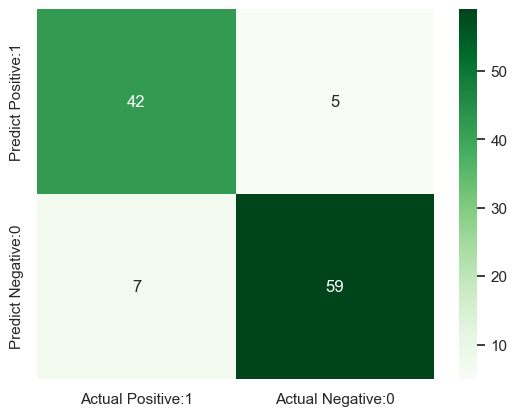

In [148]:
# visualize confusion matrix with seaborn heatmap

cm_matrix3 = pd.DataFrame(data=cm3, columns=['Actual Positive:1', 'Actual Negative:0'],
                                    index=['Predict Positive:1', 'Predict Negative:0'])

sb.heatmap(cm_matrix3, annot=True, fmt='d', cmap='Greens')

In [149]:
from sklearn.metrics import classification_report

print(classification_report(y3_test, y3_pred_default))

              precision    recall  f1-score   support

           0       1.00      0.64      0.78        47
           1       0.80      1.00      0.89        66

    accuracy                           0.85       113
   macro avg       0.90      0.82      0.83       113
weighted avg       0.88      0.85      0.84       113



In [150]:
TP3 = cm3[0,0]
TN3 = cm3[1,1]
FP3 = cm3[0,1]
FN3 = cm3[1,0]

# print classification accuracy

classification_accuracy3 = (TP3 + TN3) / float(TP3 + TN3 + FP3 + FN3)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy3))

Classification accuracy : 0.8938


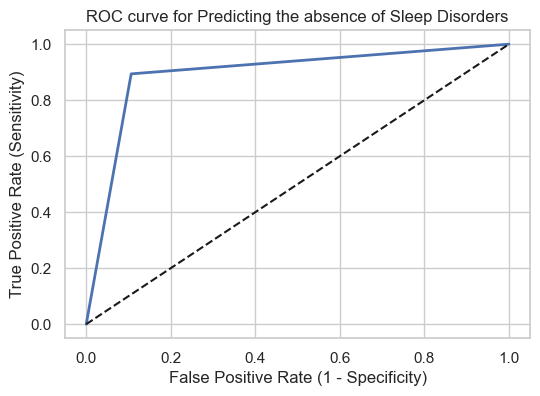

In [151]:
# plot ROC Curve

from sklearn.metrics import roc_curve

fpr3, tpr3, thresholds3 = roc_curve(y3_test, y3_pred_linear)

plt.figure(figsize=(6,4))

plt.plot(fpr3, tpr3, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for Predicting the absence of Sleep Disorders')
plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

In [152]:
# compute ROC AUC

from sklearn.metrics import roc_auc_score

ROC_AUC3 = roc_auc_score(y3_test, y3_pred_linear)

print('ROC AUC : {:.4f}'.format(ROC_AUC3))

ROC AUC : 0.8938


# Acknowledgments:
* # The Data Odyssey, Conor O'Sullivan
* https://www.youtube.com/watch?v=L8_sVRhBDLU
* https://medium.com/data-science/shap-for-categorical-features-7c63e6a554ea
* https://www.youtube.com/watch?v=2xlgOu22YgE
* https://medium.com/data-science/shap-for-binary-and-multiclass-target-variables-ff2f43de0cf4

* # Cloud and ML Online:
* https://www.youtube.com/watch?v=7sz4WpkUIIs

* # Prashant Banerjee:
* https://www.kaggle.com/code/prashant111/svm-classifier-tutorial